#### Architecture - Semantic Search using Elastic Search


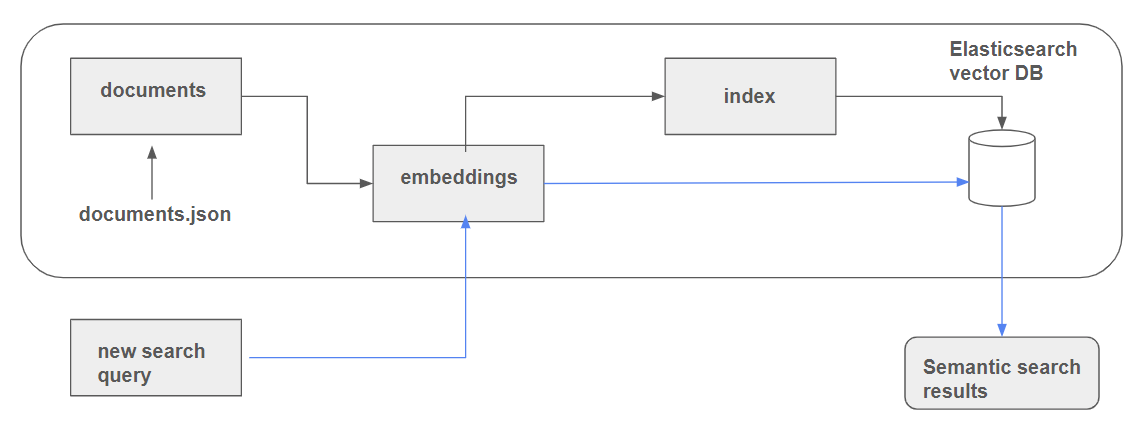

* Two very important concepts in Elasticsearch are documents and indexes.

* A document is collection of fields with their associated values. 

* To work with Elasticsearch you have to organize your data into documents, and then add all your documents to an index. 

* Index as a collection of documents that is stored in a highly optimized format designed to perform efficient searches.

#### Step 1: Prepare documents

In [6]:
import json

with open('luat_giao_duc.json', 'rt') as f_in:
    docs_raw = json.load(f_in)
# docs_raw = [docs_raw]
docs_raw

{'law_title': 'Luật Giáo Dục',
 'law_number': '43/2019/QH14',
 'chapters': [{'chapter_title': 'Chương I',
   'chapter_name': '',
   'articles': [{'article_number': '1',
     'title': 'Phạm vi điều chỉnh',
     'content': 'Luật này quy định về hệ thống giáo dục quốc dân; cơ sở giáo dục, nhà giáo, người học; quản lý nhà nước về giáo dục; quyền và trách nhiệm của cơ quan, tổ chức, cá nhân liên quan đến hoạt động giáo dục. '},
    {'article_number': '2',
     'title': 'Mục tiêu giáo dục',
     'content': 'Mục tiêu giáo dục nhằm phát triển toàn diện con người Việt Nam có đạo đức, tri thức, văn hóa, sức khỏe, thẩm mỹ và nghề nghiệp; có phẩm chất, năng lực và ý thức công dân; có lòng yêu nước, tinh thần dân tộc, trung thành với lý tưởng độc lập dân tộc và chủ nghĩa xã hội; phát huy tiềm năng, khả năng sáng tạo của mỗi cá nhân; nâng cao dân trí, phát triển nguồn nhân lực, bồi dưỡng nhân tài, đáp ứng yêu cầu của sự nghiệp xây dựng, bảo vệ Tổ quốc và hội nhập quốc tế. '},
    {'article_number': 

In [10]:
documents = []

# Flatten the structure
for chapter in docs_raw["chapters"]:
    for article in chapter["articles"]:
        # Create a new document with relevant details
        doc = {
            "law_title": docs_raw["law_title"],
            "law_number": docs_raw["law_number"],
            "chapter_title": chapter["chapter_title"],
            "article_number": article["article_number"],
            "title": article["title"],
            "content": article["content"]
        }
        # Append the document to the flat list
        documents.append(doc)


In [12]:
print(documents[1])

{'law_title': 'Luật Giáo Dục', 'law_number': '43/2019/QH14', 'chapter_title': 'Chương I', 'article_number': '2', 'title': 'Mục tiêu giáo dục', 'content': 'Mục tiêu giáo dục nhằm phát triển toàn diện con người Việt Nam có đạo đức, tri thức, văn hóa, sức khỏe, thẩm mỹ và nghề nghiệp; có phẩm chất, năng lực và ý thức công dân; có lòng yêu nước, tinh thần dân tộc, trung thành với lý tưởng độc lập dân tộc và chủ nghĩa xã hội; phát huy tiềm năng, khả năng sáng tạo của mỗi cá nhân; nâng cao dân trí, phát triển nguồn nhân lực, bồi dưỡng nhân tài, đáp ứng yêu cầu của sự nghiệp xây dựng, bảo vệ Tổ quốc và hội nhập quốc tế. '}


#### Step 2: Create Embeddings using Pretrained Models

Sentence Transformers documentation here: https://www.sbert.net/docs/sentence_transformer/pretrained_models.html

In [14]:

from sentence_transformers import SentenceTransformer
import torch
import torch.nn.functional as F

In [15]:
model = SentenceTransformer("truro7/vn-law-embedding", truncate_dim = 128)

query = "Trộm cắp sẽ bị xử lý như thế nào?" 

corpus = """

[100_2015_QH13]

LUẬT HÌNH SỰ
Điều 173. Tội trộm cắp tài sản

Khoản 1:

1. Người nào trộm cắp tài sản của người khác trị giá từ 2.000.000 đồng đến dưới 50.000.000 đồng hoặc dưới 2.000.000 đồng nhưng thuộc một trong các trường hợp sau đây, thì bị phạt cải tạo không giam giữ đến 03 năm hoặc phạt tù từ 06 tháng đến 03 năm:
a) Đã bị xử phạt vi phạm hành chính về hành vi chiếm đoạt tài sản mà còn vi phạm;
b) Đã bị kết án về tội này hoặc về một trong các tội quy định tại các điều 168, 169, 170, 171, 172, 174, 175 và 290 của Bộ luật này, chưa được xóa án tích mà còn vi phạm;
c) Gây ảnh hưởng xấu đến an ninh, trật tự, an toàn xã hội;
d) Tài sản là phương tiện kiếm sống chính của người bị hại và gia đình họ; tài sản là kỷ vật, di vật, đồ thờ cúng có giá trị đặc biệt về mặt tinh thần đối với người bị hại.
    
"""

embedding = torch.tensor([model.encode(query)])
corpus_embeddings = torch.tensor([model.encode(corpus)])

cosine_similarities = F.cosine_similarity(embedding, corpus_embeddings)

print(cosine_similarities.item()) #0.81

Invalid model-index. Not loading eval results into CardData.
Invalid model-index. Not loading eval results into CardData.


0.8144615888595581


In [19]:
embedding = torch.tensor([model.encode('đây là 1 câu nói bằng tiếng Việt')])
print(len(model.encode('đây là 1 câu nói bằng tiếng Việt')))
embedding
#UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1716905979055/work/torch/csrc/utils/tensor_new.cpp:274.)
#   embedding = torch.tensor([model.encode('đây là 1 câu nói bằng tiếng Việt')])

128


tensor([[-0.0328,  0.0029,  0.0411, -0.0379,  0.0470, -0.0664,  0.0508,  0.0177,
          0.1170,  0.0322,  0.0240, -0.0198,  0.1468, -0.0189, -0.0433, -0.0246,
         -0.0528,  0.0731, -0.0200, -0.0338, -0.0037,  0.0350, -0.0684,  0.0362,
          0.0188, -0.0146,  0.0697, -0.0692,  0.0510, -0.0020, -0.0097, -0.0776,
         -0.0435,  0.0684, -0.0079, -0.0410,  0.0217, -0.0869,  0.0702,  0.0016,
          0.0065,  0.0771,  0.0112, -0.0604,  0.0482,  0.0646,  0.0524, -0.0662,
         -0.0163, -0.0448,  0.0318, -0.0547,  0.0117,  0.0048, -0.0228,  0.0053,
         -0.0788,  0.0202,  0.0032, -0.0272,  0.0059, -0.0377,  0.0049,  0.0176,
         -0.0685, -0.0181,  0.0094, -0.0158, -0.0358,  0.0174,  0.0345,  0.0363,
         -0.1184, -0.0211, -0.0544,  0.0003,  0.0369,  0.0149, -0.0287, -0.0809,
          0.0014,  0.0168,  0.0678, -0.0203, -0.0183, -0.0072, -0.0496,  0.0267,
         -0.0332,  0.0039, -0.0221, -0.0274,  0.0482,  0.0117, -0.0241, -0.0772,
         -0.0250, -0.0090, -

In [25]:
documents[2]

{'law_title': 'Luật Giáo Dục',
 'law_number': '43/2019/QH14',
 'chapter_title': 'Chương I',
 'article_number': '3',
 'title': 'Tính chất, nguyên lý giáo dục',
 'content': '1. Nền giáo dục Việt Nam là nền giáo dục xã hội chủ nghĩa có tính nhân dân, dân tộc, khoa học, hiện đại, lấy chủ nghĩa Mác - Lê nin và tư tưởng Hồ Chí Minh làm nền tảng. 2. Hoạt động giáo dục được thực hiện theo nguyên lý học đi đôi với hành, lý luận gắn liền với thực tiễn, giáo dục nhà trường kết hợp với giáo dục gia đình và giáo dục xã hội. ',
 'title_vector': [-0.06837692111730576,
  -0.03087814897298813,
  0.05227804183959961,
  0.06872902810573578,
  -0.03519568592309952,
  -0.12437384575605392,
  0.03698962554335594,
  0.05524463579058647,
  0.08438818156719208,
  0.013893681578338146,
  -0.0010368467774242163,
  -0.024192655459046364,
  0.06982073187828064,
  0.014992638491094112,
  0.05126510187983513,
  -0.02975546196103096,
  -0.011116492561995983,
  0.04117342084646225,
  -0.06479541212320328,
  0.12947303

actual data fields (like title and content) and categorical fields (like law_title, law_number, and chapter_title). The law_title, law_number, and chapter_title fields serve as categorical data, while title and content hold the main information.

```
{
  "law_title": "Luật Giáo Dục",               // Categorical field
  "law_number": "43/2019/QH14",               // Categorical field
  "chapter_title": "Chương I",                // Categorical field
  "article_number": "2",                      // Identifier, can also be categorical
  "title": "Mục tiêu giáo dục",               // Actual data field (Title of the article)
  "content": "Mục tiêu giáo dục nhằm phát triển toàn diện con người Việt Nam có đạo đức, tri thức, văn hóa, sức khỏe, thẩm mỹ và nghề nghiệp; có phẩm chất, năng lực và ý thức công dân; có lòng yêu nước, tinh thần dân tộc, trung thành với lý tưởng độc lập dân tộc và chủ nghĩa xã hội; phát huy tiềm năng, khả năng sáng tạo của mỗi cá nhân; nâng cao dân trí, phát triển nguồn nhân lực, bồi dưỡng nhân tài, đáp ứng yêu cầu của sự nghiệp xây dựng, bảo vệ Tổ quốc và hội nhập quốc tế."  // Main content field
}

```

In [ ]:
#created the dense vector using the pre-trained model
operations = []
for doc in documents:
    # Transforming the title into an embedding using the model
    doc["title_vector"] = model.encode(doc["title"]).tolist()  # Using `title` field for embeddings
    operations.append(doc)

#only took 1 second to embedding?

In [27]:
operations[1]

{'law_title': 'Luật Giáo Dục',
 'law_number': '43/2019/QH14',
 'chapter_title': 'Chương I',
 'article_number': '2',
 'title': 'Mục tiêu giáo dục',
 'content': 'Mục tiêu giáo dục nhằm phát triển toàn diện con người Việt Nam có đạo đức, tri thức, văn hóa, sức khỏe, thẩm mỹ và nghề nghiệp; có phẩm chất, năng lực và ý thức công dân; có lòng yêu nước, tinh thần dân tộc, trung thành với lý tưởng độc lập dân tộc và chủ nghĩa xã hội; phát huy tiềm năng, khả năng sáng tạo của mỗi cá nhân; nâng cao dân trí, phát triển nguồn nhân lực, bồi dưỡng nhân tài, đáp ứng yêu cầu của sự nghiệp xây dựng, bảo vệ Tổ quốc và hội nhập quốc tế. ',
 'title_vector': [-0.05291377007961273,
  -0.0401657409965992,
  0.03198370710015297,
  0.008588402532041073,
  0.03262592479586601,
  -0.05659496411681175,
  0.07878699898719788,
  0.037880126386880875,
  0.08677902072668076,
  0.030702464282512665,
  0.01784624345600605,
  -0.011478210799396038,
  0.026204219087958336,
  0.007100487593561411,
  0.06185511499643326,
 

#### Step 3: Setup ElasticSearch connection 

In [28]:
from elasticsearch import Elasticsearch
es_client = Elasticsearch('http://localhost:9200') 

es_client.info()

ObjectApiResponse({'name': 'b55760973d4e', 'cluster_name': 'docker-cluster', 'cluster_uuid': 'vufvV6QkT0GhN1NRNRxM8Q', 'version': {'number': '8.4.3', 'build_flavor': 'default', 'build_type': 'docker', 'build_hash': '42f05b9372a9a4a470db3b52817899b99a76ee73', 'build_date': '2022-10-04T07:17:24.662462378Z', 'build_snapshot': False, 'lucene_version': '9.3.0', 'minimum_wire_compatibility_version': '7.17.0', 'minimum_index_compatibility_version': '7.0.0'}, 'tagline': 'You Know, for Search'})

#### Step 4: Create Mappings and Index

* Mapping is the process of defining how a document, and the fields it contains, are stored and indexed.

* Each document is a collection of fields, which each have their own data type.

* We can compare mapping to a database schema in how it describes the fields and properties that documents hold, the datatype of each field (e.g., string, integer, or date), and how those fields should be indexed and stored 



In [ ]:
# index_settings = {
#     "settings": {
#         "number_of_shards": 1,
#         "number_of_replicas": 0
#     },
#     "mappings": {
#         "properties": {
#             "text": {"type": "text"},
#             "section": {"type": "text"},
#             "question": {"type": "text"},
#             "course": {"type": "keyword"} ,
#             "title_vector": {"type": "dense_vector", "dims": 768, "index": True, "similarity": "cosine"}, #https://www.elastic.co/guide/en/elasticsearch/reference/current/dense-vector.html
#         }
#     }
# }
index_settings = {
    "settings": {
        "number_of_shards": 1,
        "number_of_replicas": 0
    },
    "mappings": {
        "properties": {
            "law_title": {"type": "keyword"},                
            "law_number": {"type": "keyword"},               
            "chapter_title": {"type": "keyword"},            
            "article_number": {"type": "keyword"},            
            "title": {"type": "text"},                        
            "content": {"type": "text"},                      
            "title_vector": {                                 
                "type": "dense_vector",
                "dims": 128,                                 
                "index": True,
                "similarity": "cosine"
            }
        }
    }

}


In [30]:
index_name = "legal_documents"

es_client.indices.delete(index=index_name, ignore_unavailable=True)
es_client.indices.create(index=index_name, body=index_settings)

ObjectApiResponse({'acknowledged': True, 'shards_acknowledged': True, 'index': 'legal_documents'})

#### Step 5: Add documents into index

In [31]:
for doc in operations:
    try:
        es_client.index(index=index_name, document=doc)
    except Exception as e:
        print(e)

#### Step 6: Create end user query

In [33]:
search_term = "Mục tiêu"
vector_search_term = model.encode(search_term)

In [36]:
query = {
    "field": "title_vector",
    "query_vector": vector_search_term,
    "k": 5,
    "num_candidates": 10000, 
}

In [37]:
res = es_client.search(index=index_name, knn=query, source=["text", "section", "question", "course"])
res["hits"]["hits"]

[{'_index': 'legal_documents',
  '_id': '5Ea6DpMB4aJJL9Rpjbwo',
  '_score': 0.8758552,
  '_source': {}},
 {'_index': 'legal_documents',
  '_id': '_0a6DpMB4aJJL9RpjbzK',
  '_score': 0.8112078,
  '_source': {}},
 {'_index': 'legal_documents',
  '_id': 'CUa6DpMB4aJJL9Rpjb39',
  '_score': 0.79637307,
  '_source': {}},
 {'_index': 'legal_documents',
  '_id': 'C0a6DpMB4aJJL9Rpjr0H',
  '_score': 0.7795525,
  '_source': {}},
 {'_index': 'legal_documents',
  '_id': 'Bka6DpMB4aJJL9Rpjb3r',
  '_score': 0.75784326,
  '_source': {}}]

#### Step 7: Perform Keyword search with Semantic Search (Hybrid/Advanced Search)

In [38]:
# Note: I made a minor modification to the query shown in the notebook here
# (compare to the one shown in the video)
# Included "knn" in the search query (to perform a semantic search) along with the filter  
knn_query = {
    "field": "title_vector",
    "query_vector": vector_search_term,
    "k": 5,
    "num_candidates": 10000
}

In [39]:
response = es_client.search(
    index=index_name,
    query={
        "match": {"section": "General course-related questions"},
    },
    knn=knn_query,
    size=5
)

In [40]:
response["hits"]["hits"]

[{'_index': 'legal_documents',
  '_id': '5Ea6DpMB4aJJL9Rpjbwo',
  '_score': 0.8758552,
  '_source': {'law_title': 'Luật Giáo Dục',
   'law_number': '43/2019/QH14',
   'chapter_title': 'Chương I',
   'article_number': '2',
   'title': 'Mục tiêu giáo dục',
   'content': 'Mục tiêu giáo dục nhằm phát triển toàn diện con người Việt Nam có đạo đức, tri thức, văn hóa, sức khỏe, thẩm mỹ và nghề nghiệp; có phẩm chất, năng lực và ý thức công dân; có lòng yêu nước, tinh thần dân tộc, trung thành với lý tưởng độc lập dân tộc và chủ nghĩa xã hội; phát huy tiềm năng, khả năng sáng tạo của mỗi cá nhân; nâng cao dân trí, phát triển nguồn nhân lực, bồi dưỡng nhân tài, đáp ứng yêu cầu của sự nghiệp xây dựng, bảo vệ Tổ quốc và hội nhập quốc tế. ',
   'title_vector': [-0.05291377007961273,
    -0.0401657409965992,
    0.03198370710015297,
    0.008588402532041073,
    0.03262592479586601,
    -0.05659496411681175,
    0.07878699898719788,
    0.037880126386880875,
    0.08677902072668076,
    0.0307024642

#### References

1. https://logz.io/blog/elasticsearch-mapping/#:~:text=Within%20a%20search%20engine%2C%20mapping,indexes%20and%20stores%20its%20fields

2. https://www.sbert.net/docs/sentence_transformer/pretrained_models.html

3. https://www.elastic.co/search-labs/tutorials

4. https://www.elastic.co/search-labs/blog/text-similarity-search-with-vectors-in-elasticsearch